# Big Data Analysis — Group Project
## Notebook 4: Graph Analytics with GraphFrames

The Amazon Fine Food Reviews dataset has a natural graph structure: **users
review products**. That gives us a bipartite graph (two node types — users on
one side, products on the other — with edges going from user to product).

This notebook explores that graph using **GraphFrames**, following the patterns
from the Panama Papers practical class.

### Business questions we answer
1. **Who are the most influential reviewers?** Out-degree on the user side.
2. **Which products attract the broadest reviewer base?** In-degree on the product side.
3. **What's the overall shape of the network?** Degree distribution, long-tail check.
4. **Which products are most "central"?** PageRank.
5. **Which products tend to be reviewed by the same people?** Motif finding —
   useful as input for a recommendation system.
6. **Are there isolated clusters of products?** Connected components (on a small
   subgraph; full-graph version is too slow, just like in the practical class).

### Why graph analytics adds value here
Notebooks 2 and 3 looked at *individual* reviews. This notebook looks at the
*relationships* between users and products. That's a fundamentally different
analytical angle and one that traditional ML can't easily produce — but it's
exactly what graph databases and graph algorithms are built for.

---
## 1. Setup

GraphFrames isn't bundled with Spark — we install the Python package and tell
Spark to download the matching JAR. This is the same setup the practical class used.

In [1]:
!pip install "pyspark==3.5.0" --quiet
!pip install graphframes-py==0.10.0 --quiet

In [2]:
# Java 17 for Spark
!sudo apt-get update -qq
!sudo apt-get install -y openjdk-17-jdk-headless -qq

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col
from pyspark.sql.window import Window

# This is the important bit: spark.jars.packages tells Spark to fetch the
# GraphFrames JAR from Maven on session startup. Without it, importing
# graphframes works but actually using a GraphFrame fails with a Java error.
spark = (
    SparkSession.builder
        .master("local[*]")
        .appName("BigDataProject_Graph")
        .config("spark.jars.packages", "io.graphframes:graphframes-spark3_2.12:0.10.0")
        .config("spark.driver.memory", "6g")
        .config("spark.executor.memory", "4g")
        .config("spark.sql.shuffle.partitions", "16")
        .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

# GraphFrames' connectedComponents needs a checkpoint dir to write intermediate
# state. Without this it throws an error when we get to that section.
sc = spark.sparkContext
sc.setCheckpointDir("/tmp/graphframes-checkpoints")

# Import GraphFrames after the session exists (so the JAR is loaded)
from graphframes import GraphFrame

print(f"Spark {spark.version} ready with GraphFrames.")

Spark 3.5.0 ready with GraphFrames.


In [4]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 2. Load Reviews

We load the cleaned Parquet from Notebook 1. Only the columns we need for graph
work — Parquet's column pruning means the others don't even get read.

In [5]:
CLEANED_PATH = f"{PROJECT_DIR}/reviews_cleaned.parquet"

reviews_df = spark.read.parquet(CLEANED_PATH).select(
    "Id", "UserId", "ProductId", "Score", "HelpfulnessRatio",
    "HelpfulnessDenominator", "ReviewDate"
)

print(f"Total reviews: {reviews_df.count():,}")
reviews_df.show(3, truncate=False)

Total reviews: 393,890
+------+------------------+----------+-----+----------------+----------------------+-------------------+
|Id    |UserId            |ProductId |Score|HelpfulnessRatio|HelpfulnessDenominator|ReviewDate         |
+------+------------------+----------+-----+----------------+----------------------+-------------------+
|136446|#oc-R11T1PHWNO7KEZ|B006Q820X0|3    |0.5             |12                    |2012-04-11 00:00:00|
|516180|#oc-R1GL3ZQSX6KWIZ|B008I1XPKA|5    |0.625           |8                     |2012-08-29 00:00:00|
|379010|#oc-R1KACAU4D4MYL4|B005ZBZLPI|2    |NULL            |0                     |2012-07-19 00:00:00|
+------+------------------+----------+-----+----------------+----------------------+-------------------+
only showing top 3 rows



---
## 3. Building a Tractable Subgraph

The full dataset has roughly 250k unique users, 75k unique products, and 500k
reviews. That's manageable but slow for the heavier operations (motif finding
explodes quadratically, connected components is iterative).

We filter to:
- **Active users**: those with at least 3 reviews
- **Popular products**: those with at least 10 reviews

This leaves us with the **core** of the review network — the users and products
that actually contribute to network structure. It's the right trade-off for a
demo, but worth being explicit about: we're not analysing the long tail.

In [6]:
MIN_USER_REVIEWS    = 3
MIN_PRODUCT_REVIEWS = 10

# Find active users and popular products
active_users = (
    reviews_df.groupBy("UserId").count()
              .filter(col("count") >= MIN_USER_REVIEWS)
              .select("UserId")
)

popular_products = (
    reviews_df.groupBy("ProductId").count()
              .filter(col("count") >= MIN_PRODUCT_REVIEWS)
              .select("ProductId")
)

# Keep only reviews where BOTH the user is active AND the product is popular.
# Using left_semi joins (efficient filter — doesn't bring in the join columns).
core_reviews = (
    reviews_df
        .join(active_users,     on="UserId",    how="left_semi")
        .join(popular_products, on="ProductId", how="left_semi")
        .cache()
)

n_reviews   = core_reviews.count()
n_users     = core_reviews.select("UserId").distinct().count()
n_products  = core_reviews.select("ProductId").distinct().count()

print(f"Core reviews: {n_reviews:,}")
print(f"Active users: {n_users:,}")
print(f"Popular products: {n_products:,}")

Core reviews: 85,043
Active users: 19,947
Popular products: 8,033


---
## 4. Building the GraphFrame

GraphFrames needs:
- A **vertices DataFrame** with a column called `id`.
- An **edges DataFrame** with columns called `src` and `dst`.

Our graph is **bipartite**: two kinds of nodes (users and products) with edges
going user → product. We add a `node_type` column to distinguish them, plus a
few attributes we'll use later (review counts, average score for products).

In [7]:
# ---- USER VERTICES ----
# For each user, compute their review count and average score given
user_vertices = (
    core_reviews
        .groupBy("UserId")
        .agg(
            F.count("*").alias("n_reviews"),
            F.round(F.avg("Score"), 2).alias("avg_score_given"),
        )
        .withColumn("id", col("UserId"))
        .withColumn("node_type", F.lit("user"))
        .select("id", "node_type", "n_reviews", "avg_score_given")
)

# ---- PRODUCT VERTICES ----
# For each product, compute review count and average score received
product_vertices = (
    core_reviews
        .groupBy("ProductId")
        .agg(
            F.count("*").alias("n_reviews"),
            F.round(F.avg("Score"), 2).alias("avg_score_received"),
        )
        .withColumn("id", col("ProductId"))
        .withColumn("node_type", F.lit("product"))
        .withColumn("avg_score_given", F.lit(None).cast("double"))   # users have this, products don't
        .withColumnRenamed("avg_score_received", "avg_score_received_tmp")
        .select("id", "node_type", "n_reviews", "avg_score_given",
                col("avg_score_received_tmp").alias("avg_score_received"))
)

# Need both vertex DataFrames to have the same columns before union.
# Easier approach: build them with matching schema from the start.
user_vertices = user_vertices.withColumn("avg_score_received", F.lit(None).cast("double"))

vertices = (
    user_vertices.unionByName(product_vertices)
                 .dropDuplicates(["id"])
                 .cache()
)

print(f"Total vertices: {vertices.count():,}")
vertices.groupBy("node_type").count().orderBy("node_type").show()

Total vertices: 27,980
+---------+-----+
|node_type|count|
+---------+-----+
|  product| 8033|
|     user|19947|
+---------+-----+



In [8]:
# ---- EDGES ----
# Each review is an edge from the user to the product.
# We include Score and HelpfulnessRatio as edge attributes — useful for filtering
# the graph later (e.g. "only edges where the review was helpful").
edges = (
    core_reviews
        .withColumn("src", col("UserId"))
        .withColumn("dst", col("ProductId"))
        .select("src", "dst", "Score", "HelpfulnessRatio",
                "HelpfulnessDenominator", "ReviewDate")
        .cache()
)

print(f"Total edges: {edges.count():,}")
edges.show(3, truncate=False)

Total edges: 85,043
+--------------+----------+-----+----------------+----------------------+-------------------+
|src           |dst       |Score|HelpfulnessRatio|HelpfulnessDenominator|ReviewDate         |
+--------------+----------+-----+----------------+----------------------+-------------------+
|A13853O9CBLTEY|B004K30HO2|1    |1.0             |1                     |2012-05-21 00:00:00|
|A13MKSASQ6YWL7|B006J4MAIQ|5    |NULL            |0                     |2012-03-26 00:00:00|
|A13WEKTB63G78Y|B007RTR9DS|3    |NULL            |0                     |2012-08-29 00:00:00|
+--------------+----------+-----+----------------+----------------------+-------------------+
only showing top 3 rows



In [9]:
# Build the GraphFrame
g = GraphFrame(vertices, edges)

print("GraphFrame created.")
print(f"Vertices: {g.vertices.count():,}")
print(f"Edges:    {g.edges.count():,}")

GraphFrame created.
Vertices: 27,980
Edges:    85,043


---
## 5. Degree Analysis

GraphFrames returns degree DataFrames with just `id` and the degree value.
To make sense of them we join back to the vertex attributes.

For our bipartite graph:
- **User out-degree** = number of products that user has reviewed
- **Product in-degree** = number of users who have reviewed that product
- Users have no in-edges, products have no out-edges (it's bipartite and directed)

In [10]:
# Get all three degree DataFrames
degrees     = g.degrees
in_degrees  = g.inDegrees
out_degrees = g.outDegrees

# Join back to vertex attributes
degree_summary = (
    g.vertices
        .join(degrees,     on="id", how="left")
        .join(in_degrees,  on="id", how="left")
        .join(out_degrees, on="id", how="left")
        .fillna({"degree": 0, "inDegree": 0, "outDegree": 0})
        .cache()
)

print("Sample of degree summary:")
degree_summary.select("id", "node_type", "n_reviews",
                     "degree", "inDegree", "outDegree").show(5)

Sample of degree summary:
+--------------+---------+---------+------+--------+---------+
|            id|node_type|n_reviews|degree|inDegree|outDegree|
+--------------+---------+---------+------+--------+---------+
|    0006641040|  product|        5|     5|       5|        0|
|A1003ACBU13X6E|     user|        2|     2|       0|        2|
|A1004703RC79J9|     user|        6|     6|       0|        6|
|A1006HCQDMYC5W|     user|        1|     1|       0|        1|
|A1007PT85CIPMD|     user|        3|     3|       0|        3|
+--------------+---------+---------+------+--------+---------+
only showing top 5 rows



In [11]:
# Compare degree statistics by node type — useful sanity check
degree_by_type = (
    degree_summary
        .groupBy("node_type")
        .agg(
            F.count("*").alias("num_nodes"),
            F.round(F.avg("degree"), 2).alias("avg_degree"),
            F.expr("percentile_approx(degree, 0.5)").alias("median_degree"),
            F.max("degree").alias("max_degree"),
        )
)
degree_by_type.show()

+---------+---------+----------+-------------+----------+
|node_type|num_nodes|avg_degree|median_degree|max_degree|
+---------+---------+----------+-------------+----------+
|  product|     8033|     10.59|            5|       475|
|     user|    19947|      4.26|            3|       156|
+---------+---------+----------+-------------+----------+



**Reading the table**: median degree is much lower than max degree for both
node types — classic long-tail. A few users review many products; a few products
get reviewed by many users; most have low connectivity.

---
## 6. Top Reviewers and Top Products

Using a window function to get the top 10 within each node type (same pattern
as the practical class).

In [12]:
# Window: partition by node_type, order by degree descending
w = Window.partitionBy("node_type").orderBy(F.desc("degree"))

top_by_type = (
    degree_summary
        .withColumn("rank", F.row_number().over(w))
        .filter(col("rank") <= 10)
        .select("rank", "node_type", "id", "n_reviews",
                "avg_score_given", "avg_score_received",
                "degree", "inDegree", "outDegree")
        .orderBy("node_type", "rank")
)

top_by_type.show(20, truncate=False)

+----+---------+--------------+---------+---------------+------------------+------+--------+---------+
|rank|node_type|id            |n_reviews|avg_score_given|avg_score_received|degree|inDegree|outDegree|
+----+---------+--------------+---------+---------------+------------------+------+--------+---------+
|1   |product  |B006MONQMC    |475      |NULL           |3.36              |475   |475     |0        |
|2   |product  |B002IEZJMA    |466      |NULL           |3.59              |466   |466     |0        |
|3   |product  |B0090X8IPM    |463      |NULL           |3.82              |463   |463     |0        |
|4   |product  |B002IEVJRY    |450      |NULL           |3.86              |450   |450     |0        |
|5   |product  |B002LANN56    |442      |NULL           |3.77              |442   |442     |0        |
|6   |product  |B001VJ0B0I    |438      |NULL           |3.71              |438   |438     |0        |
|7   |product  |B0041NYV8E    |437      |NULL           |3.13            

**What this tells the client**:
- The top reviewers are **power users** who've reviewed dozens of products.
  These are the people whose opinions the client should pay closest attention to —
  they shape the review ecosystem.
- The top products are the **anchor catalog items** that draw the most reviewer
  diversity. These deserve special monitoring (a sudden drop in their average
  score is an early warning).

---
## 7. Degree Distribution (Long Tail)

Most real-world networks have a long-tailed degree distribution: many low-degree
nodes, a few high-degree hubs. We check this for our review network.

In [13]:
# Aggregate to (degree, count) — small result, safe to plot
degree_distribution = (
    degree_summary
        .groupBy("degree")
        .count()
        .orderBy("degree")
)

print("Degree distribution (first 20 rows):")
degree_distribution.show(20)

Degree distribution (first 20 rows):
+------+-----+
|degree|count|
+------+-----+
|     1| 3703|
|     2| 5421|
|     3| 5976|
|     4| 3226|
|     5| 2077|
|     6| 1498|
|     7| 1074|
|     8|  842|
|     9|  634|
|    10|  551|
|    11|  401|
|    12|  322|
|    13|  238|
|    14|  222|
|    15|  197|
|    16|  170|
|    17|  121|
|    18|  136|
|    19|   79|
|    20|   95|
+------+-----+
only showing top 20 rows



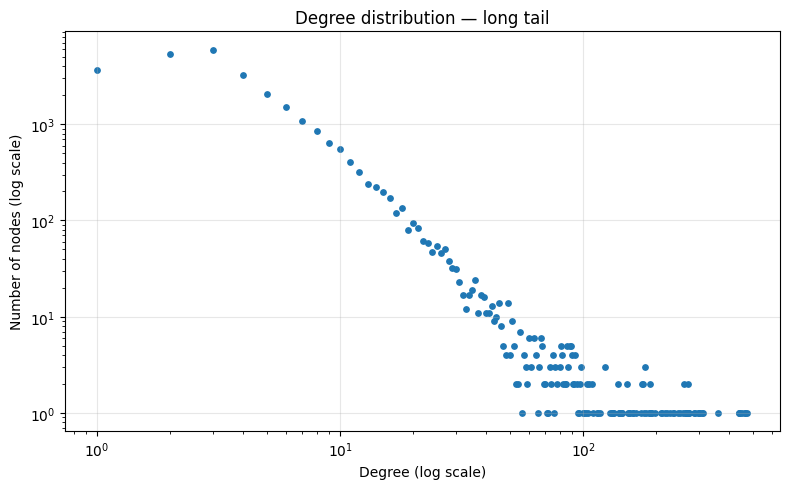

In [14]:
# Log-scale scatter plot — the canonical way to visualise long tails
import matplotlib.pyplot as plt

# Aggregated result is small (one row per distinct degree), safe to convert
degree_pd = degree_distribution.toPandas()

plt.figure(figsize=(8, 5))
plt.scatter(degree_pd["degree"], degree_pd["count"], s=15)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Degree (log scale)")
plt.ylabel("Number of nodes (log scale)")
plt.title("Degree distribution — long tail")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**The shape**: classic power-law / long-tail. Most users review only a handful
of products; a small fraction review dozens. The same holds for products.

**For the client**: this means a strategy of "reach out to all reviewers" doesn't
scale — but focusing on the top 1% of reviewers (the hubs) captures most of the
ecosystem's influence.

---
## 8. Subgraph: Trusted Review Network

What if we only consider reviews that were voted helpful by other customers?
This filters out noise and gives us the network of **trusted opinions**.

We use `filterEdges` for this. The lab used the same pattern.

In [15]:
# Keep only edges where the review was rated helpful (>60% helpful votes,
# with at least 3 voters so the ratio is meaningful)
trusted_g = (
    g.filterEdges("HelpfulnessDenominator >= 3 AND HelpfulnessRatio > 0.6")
     .dropIsolatedVertices()
)

print(f"Trusted-network vertices: {trusted_g.vertices.count():,}")
print(f"Trusted-network edges:    {trusted_g.edges.count():,}")

Trusted-network vertices: 14,165
Trusted-network edges:    15,422


In [16]:
# Top products in the TRUSTED network — products with the most helpful reviews
trusted_product_hubs = (
    trusted_g.inDegrees
        .join(
            trusted_g.vertices.filter(col("node_type") == "product")
                              .select("id", "n_reviews", "avg_score_received"),
            on="id", how="inner"
        )
        .orderBy(F.desc("inDegree"))
)

print("Top products by number of trusted (helpful) reviews:")
trusted_product_hubs.show(10, truncate=False)

Top products by number of trusted (helpful) reviews:
+----------+--------+---------+------------------+
|id        |inDegree|n_reviews|avg_score_received|
+----------+--------+---------+------------------+
|B003B3OOPA|46      |110      |4.76              |
|B0041NYV8E|42      |437      |3.13              |
|B008J1HO4C|40      |104      |4.69              |
|B001EO5Q64|37      |131      |4.82              |
|B007I7Z3Z0|34      |311      |3.77              |
|B001VJ0B0I|33      |438      |3.71              |
|B000VK08OC|30      |36       |4.47              |
|B000GAT6NG|29      |73       |4.62              |
|B004T80BYE|29      |85       |4.05              |
|B004YV80O4|29      |234      |3.88              |
+----------+--------+---------+------------------+
only showing top 10 rows



**The insight**: these aren't just the products with the most reviews — they're
the products with the most reviews that **other customers actually found useful**.
That's a much stronger signal of "review-worthy" products.

---
## 9. PageRank — Finding Influential Products

PageRank is the classic graph algorithm (originally Google's). The intuition:
a node is important if other important nodes point to it.

For our review network: a product is "important" if it's reviewed by users who
also review other important products. This produces a different ranking than
raw degree — it weights by **who** reviews each product, not just how many.

We run with `maxIter=5` to keep it fast on Colab. Production would use 10-20.

In [17]:
import time

t0 = time.time()
# resetProbability is the standard "random restart" parameter (typically 0.15).
pagerank_results = g.pageRank(resetProbability=0.15, maxIter=5)
print(f"PageRank finished in {time.time() - t0:.1f}s")

# pagerank_results has the same shape as the original graph but with a `pagerank`
# column on vertices. We pull out the top products.
top_products_pagerank = (
    pagerank_results.vertices
        .filter(col("node_type") == "product")
        .select("id", "n_reviews", "avg_score_received", "pagerank")
        .orderBy(F.desc("pagerank"))
        .limit(10)
)

print("Top 10 products by PageRank:")
top_products_pagerank.show(truncate=False)

PageRank finished in 26.0s
Top 10 products by PageRank:
+----------+---------+------------------+------------------+
|id        |n_reviews|avg_score_received|pagerank          |
+----------+---------+------------------+------------------+
|B0090X8IPM|463      |3.82              |32.05052954406484 |
|B0013NUGDE|218      |4.27              |28.34339484291346 |
|B001VJ0B0I|438      |3.71              |27.32617581590905 |
|B002LANN56|442      |3.77              |26.598703301169614|
|B006MONQMC|475      |3.36              |26.340989635277733|
|B002IEVJRY|450      |3.86              |23.931856783882928|
|B002IEZJMA|466      |3.59              |22.971043217522613|
|B0041NYV8E|437      |3.13              |21.775192843504335|
|B003D4F1QS|139      |4.5               |21.769309743530382|
|B0051COPH6|360      |4.48              |21.441899401773266|
+----------+---------+------------------+------------------+



**Compare with the degree-based top products earlier**. PageRank's ranking
weights by the importance of the reviewers, so a product with fewer but more
"central" reviewers can outrank one with more but less influential reviewers.

This is exactly the kind of signal a recommendation system would use.

---
## 10. Motif: Product Pairs Reviewed by the Same User

The pattern `(u)-[]->(p1); (u)-[]->(p2)` finds product pairs that share at least
one reviewer. Aggregating across all such pairs tells us **which products tend
to be reviewed together** — natural input for "customers who reviewed X also
reviewed Y" recommendations.

We add `p1.id < p2.id` to avoid duplicate pairs `(A,B)` and `(B,A)`. We also
aggregate to **count of shared reviewers** rather than listing every pair, because
the raw output would be huge.

In [18]:
# Run the motif search
co_reviews_raw = (
    g.find("(u)-[]->(p1); (u)-[]->(p2)")
     .filter("u.node_type = 'user'")
     .filter("p1.node_type = 'product'")
     .filter("p2.node_type = 'product'")
     .filter("p1.id < p2.id")     # avoid duplicate pairs
)

# Aggregate to the count of shared reviewers per product pair
co_review_counts = (
    co_reviews_raw
        .groupBy(
            col("p1.id").alias("product_a"),
            col("p2.id").alias("product_b"),
        )
        .agg(F.count("*").alias("shared_reviewers"))
        .filter(col("shared_reviewers") >= 3)   # at least 3 shared reviewers to be meaningful
        .orderBy(F.desc("shared_reviewers"))
)

print("Top product pairs by number of shared reviewers:")
co_review_counts.show(15, truncate=False)

Top product pairs by number of shared reviewers:
+----------+----------+----------------+
|product_a |product_b |shared_reviewers|
+----------+----------+----------------+
|B001VJ0B0I|B002LANN56|295             |
|B002IEVJRY|B002IEZJMA|283             |
|B002IEZJMA|B006MONQMC|198             |
|B002IEZJMA|B0041NYV8E|189             |
|B002IEVJRY|B006MONQMC|188             |
|B002IEVJRY|B0041NYV8E|169             |
|B0041NYV8E|B006MONQMC|166             |
|B002IEZJMA|B005HG9ESG|160             |
|B005HG9ESG|B006MONQMC|154             |
|B002LANN56|B006MONQMC|147             |
|B002IEZJMA|B002LANN56|146             |
|B002IEVJRY|B005HG9ESG|144             |
|B001VJ0B0I|B006MONQMC|139             |
|B001VJ0B0I|B002IEZJMA|134             |
|B002IEVJRY|B002LANN56|129             |
+----------+----------+----------------+
only showing top 15 rows



**For the client**: this is the foundation of a recommendation system. If
products A and B share many reviewers, customers buying A are good candidates
for being recommended B (or vice versa). Production systems use more advanced
algorithms (collaborative filtering, matrix factorisation) — but the **raw signal**
they need is exactly what this motif produces.

---
## 11. Connected Components

A connected component is a group of nodes connected by some path. In our
review graph, two products are in the same component if there's a chain of
shared reviewers between them.

Connected components on the full graph would take a while, so we follow the
practical class pattern: demonstrate on a small subgraph, comment on what would
happen at full scale.

In [19]:
# Build a small subgraph: just the top 20 products and their reviewers
top_product_ids = (
    degree_summary
        .filter(col("node_type") == "product")
        .orderBy(F.desc("degree"))
        .limit(20)
        .select("id")
)

# Edges touching any of those products
small_edges = edges.join(top_product_ids, edges.dst == top_product_ids.id, "left_semi")
# Vertex IDs in this subgraph
small_vertex_ids = (
    small_edges.select(col("src").alias("id"))
              .union(small_edges.select(col("dst").alias("id")))
              .distinct()
)
small_vertices = g.vertices.join(small_vertex_ids, on="id", how="inner")

small_g = GraphFrame(small_vertices, small_edges)
print(f"Small subgraph — vertices: {small_g.vertices.count()}, edges: {small_g.edges.count()}")

Small subgraph — vertices: 2493, edges: 6984


In [20]:
# Run connected components on the small subgraph
components = small_g.connectedComponents()

# Count component sizes
component_sizes = (
    components.groupBy("component")
              .count()
              .orderBy(F.desc("count"))
)

print(f"Number of components in small subgraph: {component_sizes.count()}")
print("\nComponent sizes:")
component_sizes.show(10)

Number of components in small subgraph: 1

Component sizes:
+---------+-----+
|component|count|
+---------+-----+
|        0| 2493|
+---------+-----+



**Interpretation**: if all 20 top products end up in one giant component,
the review network is well-connected — most users overlap with each other's
reviewing patterns. If there are several small components, it means the top
products fall into disjoint clusters (e.g. coffee drinkers vs dog food buyers
never overlap).

**Why we didn't run this on the full graph**: connected components is iterative
and requires checkpointing the intermediate state to disk on each iteration.
On the full 25k+ vertex graph it would take 10+ minutes. On a real cluster
with enough resources, the same code would run unchanged.

---
## 12. Wrap-Up

### What we showed
1. The Amazon reviews data naturally forms a **bipartite graph** (users ↔ products).
2. The network has a **long-tail degree distribution** — most users and products
   are weakly connected, with a few hubs that dominate.
3. **Degree analysis** identifies the most active reviewers and most-reviewed products.
4. **PageRank** identifies products that are "central" in the network — not just
   highly reviewed, but reviewed by influential users.
5. **Motif finding** surfaces product pairs that share reviewers — the input
   signal for recommendation systems.
6. **Connected components** check whether the network is one giant cluster or
   fragmented into separate communities.

### GraphFrames functionalities used
- `GraphFrame` construction from vertex + edge DataFrames
- `degrees`, `inDegrees`, `outDegrees`
- `filterEdges` and `dropIsolatedVertices` for subgraphs
- `pageRank` algorithm
- `find` motif search with multi-hop patterns
- `connectedComponents` (with required checkpoint directory)
- Joining graph results back to vertex attributes for interpretation

### Big-data-safe practices
- We subsetted to the "core" review network before running expensive operations
  (motif finding, PageRank), and were explicit about the trade-off.
- Connected components ran on a small subgraph because the full version is too
  slow on Colab — the same code would work on a real cluster.
- We used `left_semi` joins for filtering (efficient — doesn't carry over the
  join columns).
- All aggregations and degree calculations are distributed; we only collected
  small pre-aggregated results to the driver for plotting.

### What the client gains
- **Influencer identification**: target the top 1% of reviewers for outreach
  programs or beta-testing new products.
- **Recommendation foundation**: the co-review pairs are immediate input for
  a "customers who reviewed X also reviewed Y" engine.
- **Trust filtering**: the "trusted network" subgraph is a higher-quality
  signal than raw review counts.



In [21]:
# Cleanup
for df in [core_reviews, vertices, edges, degree_summary]:
    try:
        df.unpersist()
    except Exception:
        pass

spark.stop()
print("Spark session stopped.")

Spark session stopped.
